# Finansal Varlıklar Arası İlişkilerin Sosyal Ağ Analizi

Bu çalışmada, farklı finansal varlıklar arasındaki ilişki yapısını sosyal ağ analizi yaklaşımıyla incelemeyi amaçladım. Finansal piyasalar genellikle tek tek varlıkların fiyat hareketleriyle değerlendirilir. Ancak bu varlıklar zaman içinde birbirleriyle benzer ya da ters yönlü hareket edebilir. Bu nedenle finansal sistemi bir ağ gibi ele almak, piyasanın genel bağlantı düzenini daha anlaşılır hale getirir.

Analizde her finansal varlık bir düğüm olarak tanımlandı. İki varlık arasında yeterince güçlü korelasyon ilişkisi varsa bu ilişki ağda bir kenar olarak gösterildi. Böylece hangi varlıkların birlikte hareket ettiği, hangi varlıkların merkezde yer aldığı ve hangi grupların kendi içinde kümelendiği birlikte incelenebildi.

## 1. Kurulum, Kütüphaneler ve Dosya Yolları

Analize başlarken gerekli kütüphaneleri ve dosya yollarını tanımladım. Veri okuma ve düzenleme için `pandas`, sayısal işlemler için `numpy`, grafikler için `matplotlib` ve `seaborn`, ağ yapısını kurmak ve ağ ölçütlerini hesaplamak için `networkx` kullanıldı. Topluluk analizi için Louvain yönteminden yararlanıldı.

Dosya yollarını başta tanımlamak, analiz sürecini daha düzenli hale getirir. Ham veri, işlenmiş veri, korelasyon matrisi, kenar listesi, metrik dosyaları ve görseller aynı klasör yapısı içinde saklanır. Korelasyon eşiği `0.40` olarak belirlendi. Bu eşik, çok zayıf ilişkileri dışarıda bırakıp daha okunabilir bir finansal ağ kurmak için kullanıldı.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import community as community_louvain

plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid")

BASE_DIR = Path.cwd()
RAW_PATH = BASE_DIR / "data" / "raw" / "financial_prices_2014_2024.csv"
RETURNS_PATH = BASE_DIR / "data" / "processed" / "returns_2014_2024.csv"
PRE_CRISIS_PATH = BASE_DIR / "data" / "processed" / "returns_pre_crisis.csv"
POST_CRISIS_PATH = BASE_DIR / "data" / "processed" / "returns_post_crisis.csv"
CORR_PATH = BASE_DIR / "outputs" / "metrics" / "correlation_matrix.csv"
EDGE_PATH = BASE_DIR / "data" / "edges" / "network_edges.csv"

GRAPH_DIR = BASE_DIR / "outputs" / "graphs"
HEATMAP_DIR = BASE_DIR / "outputs" / "heatmaps"
METRICS_DIR = BASE_DIR / "outputs" / "metrics"

for directory in [RAW_PATH.parent, RETURNS_PATH.parent, EDGE_PATH.parent, GRAPH_DIR, HEATMAP_DIR, METRICS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

THRESHOLD = 0.40
START_DATE = "2014-01-01"
END_DATE = "2024-12-31"

## 2. Finansal Varlıklar ve Veri Kaynağı

Analizde farklı piyasa alanlarını temsil eden 18 finansal varlık kullandım. Veri setinde değerli metaller, enerji varlıkları, küresel hisse senedi endeksleri, Türkiye piyasasına ait göstergeler, döviz kurları, Bitcoin, VIX, ABD 10 yıllık tahvil faizi ve dolar endeksi yer aldı. Bu çeşitlilik, farklı finansal segmentler arasındaki ilişkileri aynı ağ içinde görmeyi sağladı.

Veriler Yahoo Finance kaynağından alındı. Hazır bir ağ verisi kullanmak yerine önce fiyat serileri toplandı, daha sonra bu fiyatlar günlük getirilere dönüştürüldü. Ardından korelasyon matrisi hesaplandı ve bu matristen hareketle kenar listesi oluşturuldu. Bu nedenle analizde kullanılan ağ verisi doğrudan bu çalışma içinde üretildi.

In [2]:
TICKERS = {
    "Gold": "GC=F",
    "Silver": "SI=F",
    "Brent_Oil": "BZ=F",
    "WTI_Oil": "CL=F",
    "Natural_Gas": "NG=F",
    "SP500": "^GSPC",
    "NASDAQ": "^IXIC",
    "Dow_Jones": "^DJI",
    "DAX": "^GDAXI",
    "FTSE100": "^FTSE",
    "Nikkei225": "^N225",
    "BIST100": "XU100.IS",
    "USD_TRY": "TRY=X",
    "EUR_TRY": "EURTRY=X",
    "Bitcoin": "BTC-USD",
    "VIX": "^VIX",
    "US_10Y_Bond": "^TNX",
    "Dollar_Index": "DX-Y.NYB",
}

assets = list(TICKERS.keys())
pd.DataFrame({"Asset": TICKERS.keys(), "Yahoo_Finance_Code": TICKERS.values()})

,Asset,Yahoo_Finance_Code
0,Gold,GC=F
1,Silver,SI=F
2,Brent_Oil,BZ=F
3,WTI_Oil,CL=F
4,Natural_Gas,NG=F
5,SP500,^GSPC
6,NASDAQ,^IXIC
7,Dow_Jones,^DJI
8,DAX,^GDAXI
9,FTSE100,^FTSE


## 3. Ham Verinin Okunması veya İndirilmesi

Bu bölümde fiyat verilerini analize hazır hale getirdim. Ham fiyat verisi dosyada varsa doğrudan okundu. Dosya yoksa aynı finansal varlık listesiyle Yahoo Finance üzerinden veri indirme işlemi yapılacak şekilde akış kuruldu. Bu yapı, analizi yeniden çalıştırmayı kolaylaştırır.

Fiyat verileri her varlık için aynı tarih aralığında toplanmaya çalışıldı. Finansal piyasaların işlem günleri farklı olabildiği için sonraki adımlarda ortak tarihli ve temiz bir veri seti oluşturmak gerekir. Bu aşama, analiz zincirinin veri toplama basamağıdır.

In [3]:
def download_price_data():
    import yfinance as yf

    price_data = pd.DataFrame()
    for asset_name, ticker in TICKERS.items():
        data = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False)
        if data.empty:
            print(f"Uyar?: {asset_name} i?in veri gelmedi.")
            continue
        if "Adj Close" in data.columns:
            price_data[asset_name] = data["Adj Close"]
        elif "Close" in data.columns:
            price_data[asset_name] = data["Close"]
        else:
            print(f"Uyar?: {asset_name} i?in Close/Adj Close kolonu bulunamad?.")
    price_data.to_csv(RAW_PATH)
    return price_data

if RAW_PATH.exists():
    prices = pd.read_csv(RAW_PATH, index_col="Date", parse_dates=True)
else:
    prices = download_price_data()

prices.head()

,Gold,Silver,Brent_Oil,WTI_Oil,Natural_Gas,SP500,NASDAQ,Dow_Jones,DAX,FTSE100,Nikkei225,BIST100,USD_TRY,EUR_TRY,Bitcoin,VIX,US_10Y_Bond,Dollar_Index
Date,,,,,,,,,,,,,,,,,,
2014-01-02,1225.000000,20.098000,107.779999,95.440002,4.321,1831.979980,4143.069824,16441.349609,9400.040039,6717.899902,NaN,669.854431,2.14640,2.95518,NaN,14.23,2.985,80.629997
2014-01-03,1238.400024,20.181999,106.889999,93.959999,4.304,1831.369995,4131.910156,16469.990234,9435.150391,6730.700195,NaN,659.667542,2.16867,2.96316,NaN,13.76,2.995,80.790001
2014-01-06,1237.800049,20.077000,106.730003,93.430000,4.306,1826.770020,4113.680176,16425.099609,9428.000000,6730.700195,15908.879883,680.216370,2.17490,2.95804,NaN,13.55,2.961,80.650002
2014-01-07,1229.400024,19.764999,107.349998,93.669998,4.299,1837.880005,4153.180176,16530.939453,9506.200195,6755.500000,15814.370117,685.982361,2.16958,2.95703,NaN,12.92,2.937,80.830002
2014-01-08,1225.300049,19.518000,107.150002,92.330002,4.216,1837.489990,4165.609863,16462.740234,9497.839844,6721.799805,16121.450195,673.313416,2.16597,2.94895,NaN,12.87,2.993,81.040001


## 4. Veri Ön İşleme

Finansal varlıkların fiyat seviyeleri doğrudan karşılaştırmaya uygun değildir. Bitcoin, petrol, altın, borsa endeksi ve döviz kuru birbirinden çok farklı fiyat ölçeklerine sahiptir. Bu nedenle analizde ham fiyatlar yerine günlük yüzde getiriler kullanıldı. Günlük getiri, bir varlığın bir önceki işlem gününe göre ne kadar değiştiğini gösterir.

Getiri serileri hesaplandıktan sonra eksik değer içeren satırlar temizlendi. Bu işlem farklı piyasa takvimleri nedeniyle önemlidir. Kripto varlıklar hafta sonu işlem görebilirken hisse senedi endeksleri veya emtia piyasaları aynı günlerde kapalı olabilir. Ortak ve temiz tarih aralığı elde edildikten sonra korelasyon analizi daha sağlıklı biçimde yapılabilir.

In [4]:
returns = prices.pct_change().dropna()
returns.to_csv(RETURNS_PATH)
returns.loc["2014":"2019"].to_csv(PRE_CRISIS_PATH)
returns.loc["2020":"2024"].to_csv(POST_CRISIS_PATH)

summary = pd.DataFrame({
    "Metric": ["Start date", "End date", "Observation count", "Asset count"],
    "Value": [returns.index.min().date(), returns.index.max().date(), len(returns), returns.shape[1]],
})
summary

,Metric,Value
0,Start date,2014-09-18
1,End date,2024-12-30
2,Observation count,2075
3,Asset count,18


## 5. Korelasyon Matrisi

Bu aşamada finansal varlıkların günlük getiri serileri arasındaki Pearson korelasyon katsayıları hesaplandı. Korelasyon katsayısı, iki varlığın birlikte hareket etme eğilimini gösterir. Pozitif değerler benzer yönlü hareketi, negatif değerler ters yönlü hareketi, sıfıra yakın değerler ise zayıf ilişkiyi ifade eder.

Korelasyon matrisi ağın temelini oluşturur. İki varlık arasındaki korelasyonun mutlak değeri belirlenen eşiğin üzerindeyse bu iki varlık arasında bir bağlantı kuruldu. Bu çalışmada hem güçlü pozitif ilişkiler hem de güçlü negatif ilişkiler dikkate alındı.

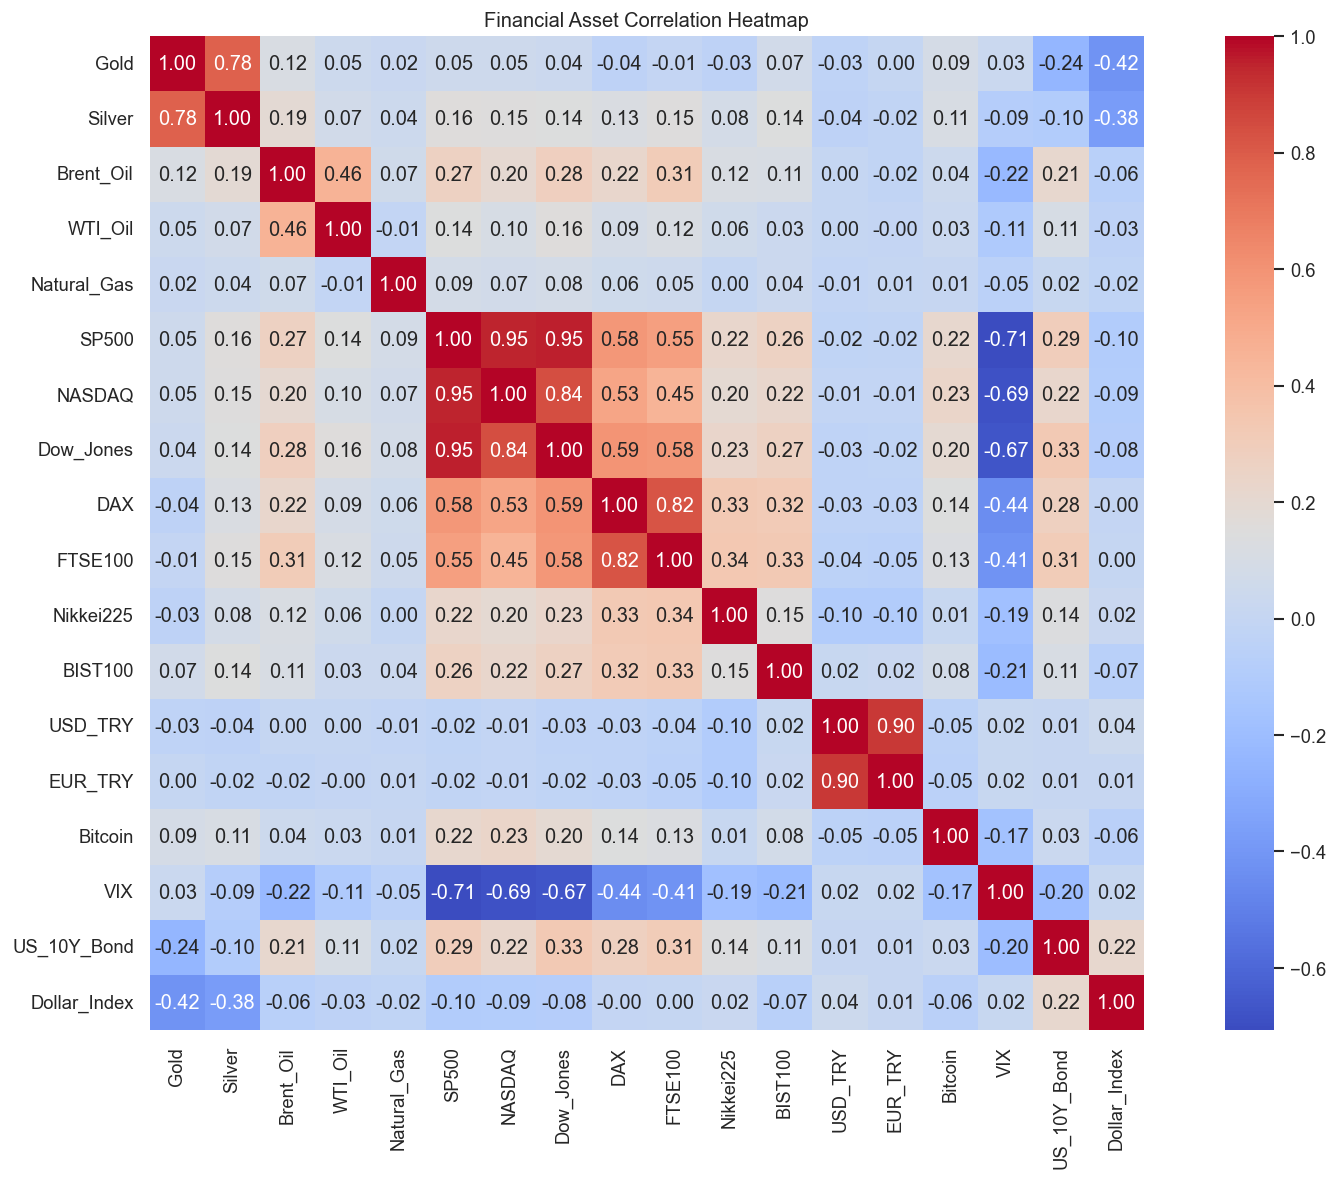

In [5]:
correlation_matrix = returns.corr(method="pearson")
correlation_matrix.to_csv(CORR_PATH)

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Financial Asset Correlation Heatmap")
plt.tight_layout()
plt.savefig(HEATMAP_DIR / "correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Ağ Modelleme

Bu bölümde finansal varlıklar bir graf yapısına dönüştürüldü. Graf yapısında düğümler finansal varlıkları, kenarlar ise varlıklar arasındaki güçlü korelasyon ilişkilerini temsil eder. Matematiksel olarak ağ `G = (V, E)` biçiminde düşünülebilir.

Kurulan ağ yönsüz ve ağırlıklıdır. Yönsüz olmasının nedeni korelasyon ilişkisinin iki taraflı olmasıdır. Ağırlıklı olmasının nedeni ise her kenarın kendi korelasyon katsayısını taşımasıdır. Kenar listesinde bu yüzden `source`, `target` ve `weight` alanları yer alır.

In [6]:
G = nx.Graph()
G.add_nodes_from(assets)

for i, asset_1 in enumerate(correlation_matrix.columns):
    for asset_2 in correlation_matrix.columns[i + 1:]:
        corr_value = correlation_matrix.loc[asset_1, asset_2]
        if abs(corr_value) >= THRESHOLD:
            G.add_edge(asset_1, asset_2, weight=float(corr_value))

edge_df = nx.to_pandas_edgelist(G)
edge_df.to_csv(EDGE_PATH, index=False)

print(f"Node count: {G.number_of_nodes()}")
print(f"Edge count: {G.number_of_edges()}")
edge_df.head(10)

Node count: 18
Edge count: 19


,source,target,weight
0,Gold,Silver,0.780958
1,Gold,Dollar_Index,-0.419023
2,Brent_Oil,WTI_Oil,0.455011
3,SP500,NASDAQ,0.948988
4,SP500,Dow_Jones,0.954677
5,SP500,DAX,0.584371
6,SP500,FTSE100,0.549876
7,SP500,VIX,-0.707123
8,NASDAQ,Dow_Jones,0.840383
9,NASDAQ,DAX,0.525171


## 7. Komşuluk Matrisi ve Aktif Alt Ağ

Komşuluk matrisi, ağdaki düğümlerin birbirleriyle bağlantılı olup olmadığını tablo biçiminde gösterir. Bu çalışmada matris değerleri yalnızca bağlantı varlığını değil, aynı zamanda bağlantının korelasyon ağırlığını da ifade eder.

Korelasyon eşiği uygulandıktan sonra bazı varlıklar ağda izole kalabilir. Yani bu varlıkların seçilen eşik değerine göre yeterince güçlü bağlantısı bulunmayabilir. Bu nedenle hem tüm varlıkları içeren tam ağ hem de yalnızca en az bir bağlantısı bulunan düğümlerden oluşan aktif alt ağ ayrı ayrı incelendi.

In [7]:
adjacency_matrix = nx.to_pandas_adjacency(G, weight="weight")
active_nodes = [node for node, degree in G.degree() if degree > 0]
active_G = G.subgraph(active_nodes).copy()

print(f"Active node count: {active_G.number_of_nodes()}")
print(f"Active edge count: {active_G.number_of_edges()}")
adjacency_matrix.round(2)

Active node count: 13
Active edge count: 19


,Gold,Silver,Brent_Oil,WTI_Oil,Natural_Gas,SP500,NASDAQ,Dow_Jones,DAX,FTSE100,Nikkei225,BIST100,USD_TRY,EUR_TRY,Bitcoin,VIX,US_10Y_Bond,Dollar_Index
Gold,0.00,0.78,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,-0.42
Silver,0.78,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00
Brent_Oil,0.00,0.00,0.00,0.46,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00
WTI_Oil,0.00,0.00,0.46,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00
Natural_Gas,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00
SP500,0.00,0.00,0.00,0.00,0.0,0.00,0.95,0.95,0.58,0.55,0.0,0.0,0.0,0.0,0.0,-0.71,0.0,0.00
NASDAQ,0.00,0.00,0.00,0.00,0.0,0.95,0.00,0.84,0.53,0.45,0.0,0.0,0.0,0.0,0.0,-0.69,0.0,0.00
Dow_Jones,0.00,0.00,0.00,0.00,0.0,0.95,0.84,0.00,0.59,0.58,0.0,0.0,0.0,0.0,0.0,-0.67,0.0,0.00
DAX,0.00,0.00,0.00,0.00,0.0,0.58,0.53,0.59,0.00,0.82,0.0,0.0,0.0,0.0,0.0,-0.44,0.0,0.00
FTSE100,0.00,0.00,0.00,0.00,0.0,0.55,0.45,0.58,0.82,0.00,0.0,0.0,0.0,0.0,0.0,-0.41,0.0,0.00


## 8. Temel Ağ Ölçütleri

Bu bölümde ağın genel yapısını anlamak için temel ölçütler hesaplandı. Düğüm sayısı ağdaki finansal varlık sayısını, kenar sayısı güçlü ilişki sayısını, yoğunluk ise gerçekleşen bağlantıların olası tüm bağlantılara oranını gösterir.

Bileşen sayısı, ağın kaç ayrı parçadan oluştuğunu gösterir. En büyük bileşenin çapı, o bileşen içindeki en uzun en kısa yol hakkında bilgi verir. Ortalama kümeleme katsayısı ise varlıkların kendi yakın çevrelerinde ne kadar kümelendiğini gösterir.

In [8]:
def graph_summary(graph, label):
    components = list(nx.connected_components(graph))
    largest_component = graph.subgraph(max(components, key=len)).copy() if components else nx.Graph()
    diameter = nx.diameter(largest_component) if largest_component.number_of_nodes() > 1 else 0
    return {
        "Network": label,
        "Nodes": graph.number_of_nodes(),
        "Edges": graph.number_of_edges(),
        "Density": nx.density(graph),
        "Average degree": (2 * graph.number_of_edges() / graph.number_of_nodes()) if graph.number_of_nodes() else 0,
        "Connected components": len(components),
        "Largest component size": largest_component.number_of_nodes(),
        "Largest component diameter": diameter,
        "Average clustering": nx.average_clustering(graph) if graph.number_of_nodes() else 0,
    }

summary_df = pd.DataFrame([
    graph_summary(G, "Full network including isolated nodes"),
    graph_summary(active_G, "Active network excluding isolated nodes"),
])
summary_df.to_csv(METRICS_DIR / "global_network_metrics.csv", index=False)
summary_df

,Network,Nodes,Edges,Density,Average degree,Connected components,Largest component size,Largest component diameter,Average clustering
0,Full network including isolated nodes,18,19,0.124183,2.111111,9,6,1,0.333333
1,Active network excluding isolated nodes,13,19,0.243590,2.923077,4,6,1,0.461538


## 9. Ağ Görselleştirmesi

Bu bölümde oluşturulan finansal ağ görsel olarak incelendi. Görselde düğüm boyutu ve rengi degree centrality değerine göre belirlendi. Daha fazla bağlantıya sahip olan varlıklar ağ içinde daha büyük ve daha belirgin görünür.

Kenar renkleri ilişkinin yönünü gösterir. Pozitif korelasyonlar kırmızı, negatif korelasyonlar mavi olarak çizildi. Kenar kalınlığı ise ilişkinin gücünü temsil eder. Bu görselleştirme sayesinde bağlantıların yönü ve şiddeti birlikte okunabilir.

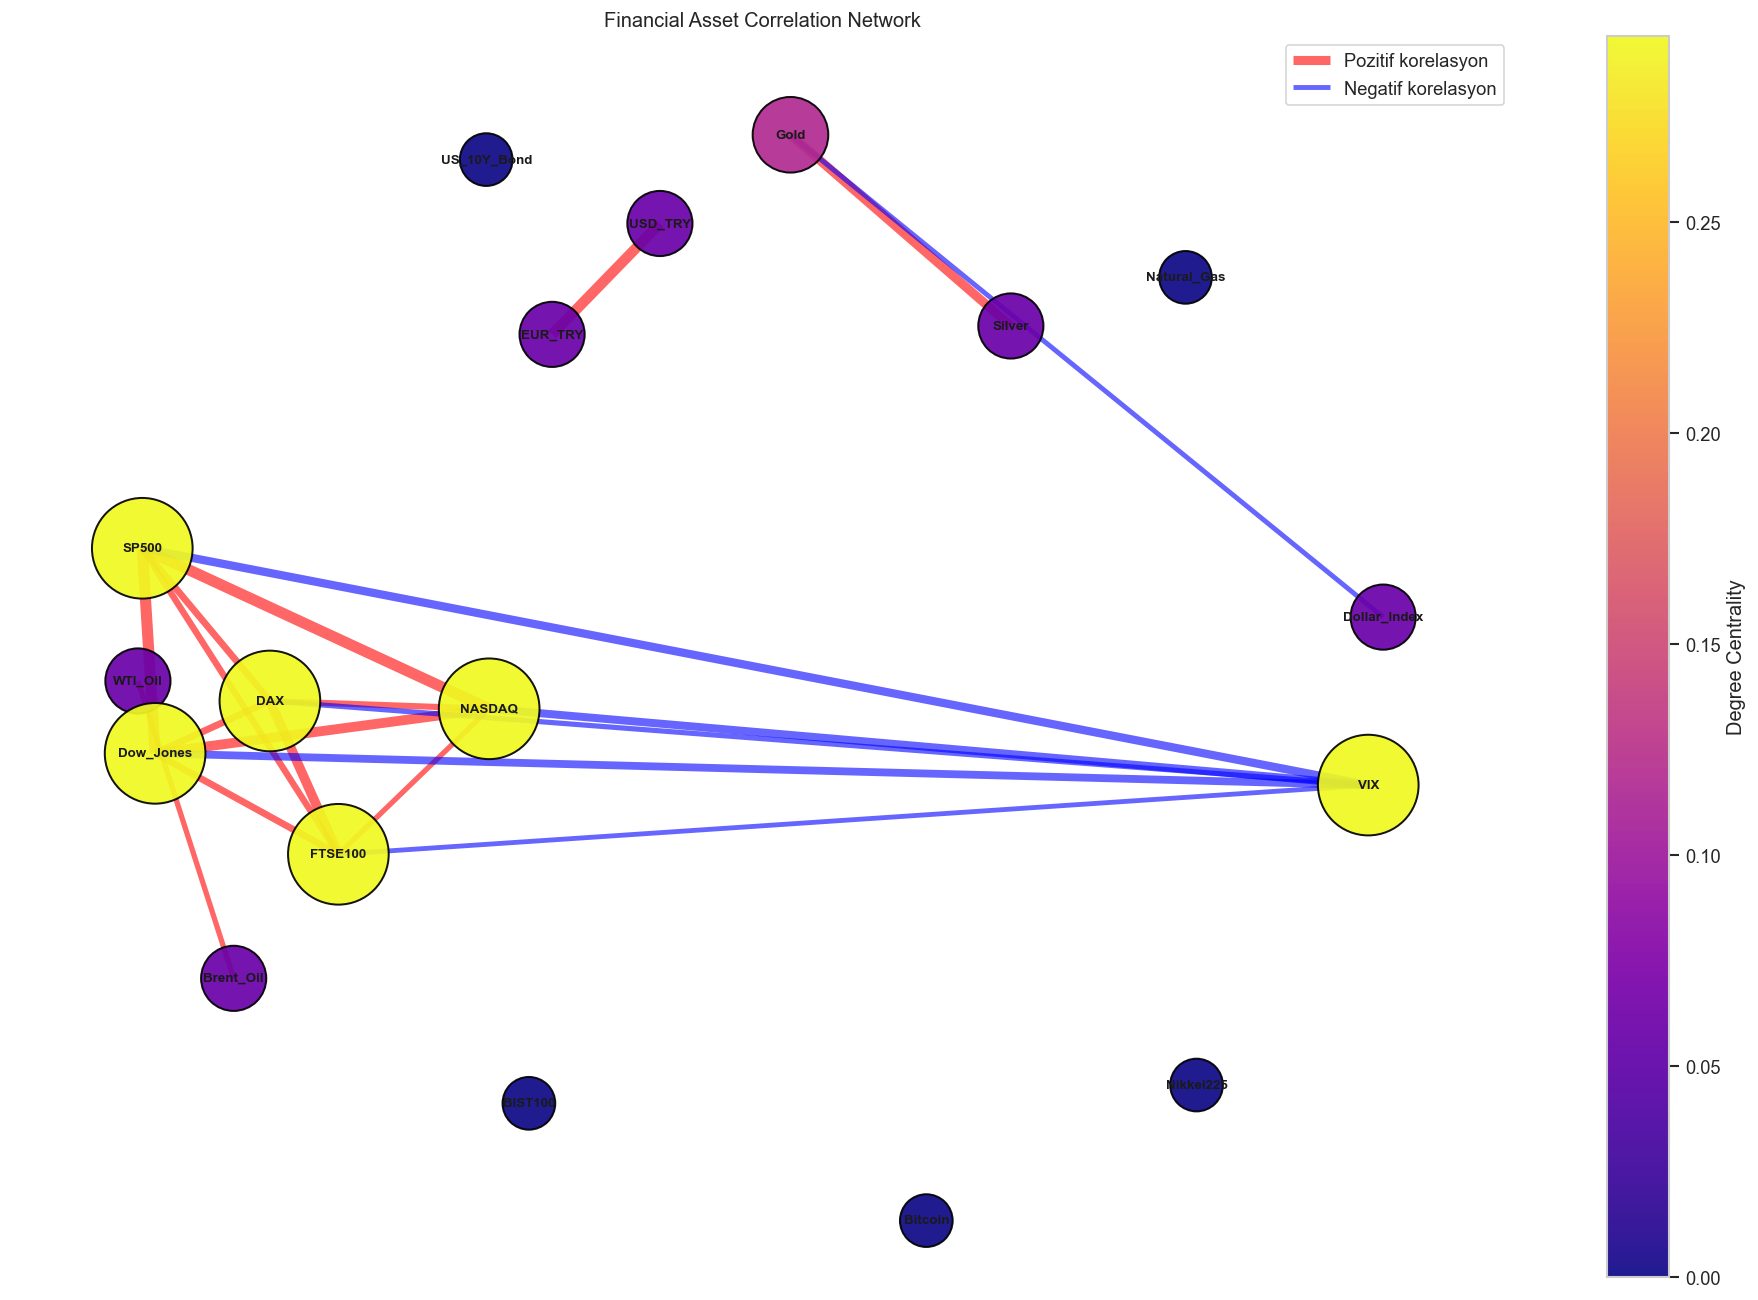

In [9]:
pos = nx.spring_layout(G, seed=42, k=1.3, iterations=100)
degree_centrality = nx.degree_centrality(G)

node_sizes = [degree_centrality[node] * 9000 + 1000 for node in G.nodes()]
node_colors = [degree_centrality[node] for node in G.nodes()]
positive_edges = [(u, v) for u, v in G.edges() if G[u][v]["weight"] > 0]
negative_edges = [(u, v) for u, v in G.edges() if G[u][v]["weight"] < 0]

plt.figure(figsize=(16, 11))
nodes = nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, cmap=plt.cm.plasma, edgecolors="black", linewidths=1.2, alpha=0.92)
nx.draw_networkx_edges(G, pos, edgelist=positive_edges, width=[abs(G[u][v]["weight"]) * 7 for u, v in positive_edges], edge_color="red", alpha=0.6, label="Pozitif korelasyon")
nx.draw_networkx_edges(G, pos, edgelist=negative_edges, width=[abs(G[u][v]["weight"]) * 7 for u, v in negative_edges], edge_color="blue", alpha=0.6, label="Negatif korelasyon")
nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold")
plt.colorbar(nodes, label="Degree Centrality")
plt.legend(loc="upper right")
plt.title("Financial Asset Correlation Network")
plt.axis("off")
plt.tight_layout()
plt.savefig(GRAPH_DIR / "network_graph_enhanced.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Merkezilik Analizi

Merkezilik ölçütleri, ağ içindeki düğümlerin önemini farklı açılardan değerlendirmeyi sağlar. Degree centrality en çok bağlantıya sahip varlıkları gösterir. Betweenness centrality, farklı düğümler arasındaki yollar üzerinde aracılık eden varlıkları öne çıkarır.

Finansal açıdan bu ölçütler oldukça anlamlıdır. Çok bağlantılı bir endeks piyasanın genel hareketleriyle yakın ilişkili olabilir. Köprü rolündeki bir varlık, farklı piyasa grupları arasında geçiş noktası gibi davranabilir.

In [10]:
centrality_df = pd.DataFrame({
    "Degree_Centrality": pd.Series(nx.degree_centrality(G)),
    "Betweenness_Centrality": pd.Series(nx.betweenness_centrality(G, weight="weight")),
    "Closeness_Centrality": pd.Series(nx.closeness_centrality(G)),
    "Eigenvector_Centrality": pd.Series(nx.eigenvector_centrality(G, max_iter=1000)),
    "Clustering_Coefficient": pd.Series(nx.clustering(G)),
})
centrality_df.to_csv(METRICS_DIR / "network_metrics.csv")
centrality_df.sort_values("Degree_Centrality", ascending=False).head(10)

,Degree_Centrality,Betweenness_Centrality,Closeness_Centrality,Eigenvector_Centrality,Clustering_Coefficient
DAX,0.294118,0.000000,0.294118,4.082483e-01,1.0
SP500,0.294118,0.000000,0.294118,4.082483e-01,1.0
FTSE100,0.294118,0.000000,0.294118,4.082483e-01,1.0
VIX,0.294118,0.073529,0.294118,4.082483e-01,1.0
Dow_Jones,0.294118,0.000000,0.294118,4.082483e-01,1.0
NASDAQ,0.294118,0.000000,0.294118,4.082483e-01,1.0
Gold,0.117647,0.007353,0.117647,3.570982e-06,0.0
Silver,0.058824,0.000000,0.078431,2.525066e-06,0.0
WTI_Oil,0.058824,0.000000,0.058824,2.560637e-07,0.0
Brent_Oil,0.058824,0.000000,0.058824,2.560637e-07,0.0


In [11]:
top5_tables = {}
for column in ["Degree_Centrality", "Betweenness_Centrality", "Closeness_Centrality", "Eigenvector_Centrality"]:
    top5_tables[column] = centrality_df.sort_values(column, ascending=False).head(5)[[column]]
    print(f"Top 5 - {column}")
    display(top5_tables[column])

Top 5 - Degree_Centrality


,Degree_Centrality
DAX,0.294118
SP500,0.294118
FTSE100,0.294118
VIX,0.294118
Dow_Jones,0.294118


Top 5 - Betweenness_Centrality


,Betweenness_Centrality
VIX,0.073529
Gold,0.007353
Silver,0.000000
Brent_Oil,0.000000
Natural_Gas,0.000000


Top 5 - Closeness_Centrality


,Closeness_Centrality
DAX,0.294118
SP500,0.294118
FTSE100,0.294118
VIX,0.294118
Dow_Jones,0.294118


Top 5 - Eigenvector_Centrality


,Eigenvector_Centrality
DAX,0.408248
SP500,0.408248
FTSE100,0.408248
VIX,0.408248
Dow_Jones,0.408248


## 11. Derece Dağılımı

Derece dağılımı, her düğümün kaç bağlantıya sahip olduğunu gösterir. Bu grafik, ağda bazı varlıkların diğerlerine göre daha fazla ilişki kurup kurmadığını anlamak için kullanıldı.

Finansal ağ bağlamında yüksek dereceye sahip varlıklar, farklı piyasa göstergeleriyle daha fazla birlikte hareket eden varlıklardır. Bu nedenle derece dağılımı, merkezilik tablosunu destekleyen sade bir özet sunar.

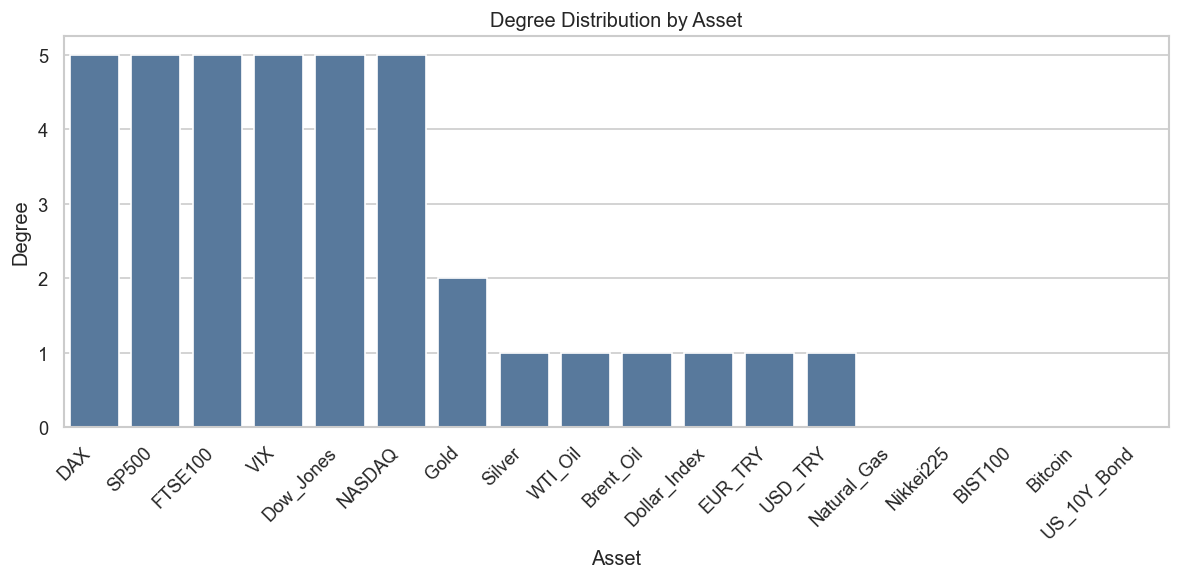

,Degree
DAX,5
SP500,5
FTSE100,5
VIX,5
Dow_Jones,5
NASDAQ,5
Gold,2
Silver,1
WTI_Oil,1
Brent_Oil,1


In [12]:
degree_series = pd.Series(dict(G.degree()), name="Degree").sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=degree_series.index, y=degree_series.values, color="#4C78A8")
plt.title("Degree Distribution by Asset")
plt.ylabel("Degree")
plt.xlabel("Asset")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(GRAPH_DIR / "degree_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

degree_series.to_frame()

## 12. Topluluk Analizi

Topluluk analizi, ağ içinde birbirleriyle daha yoğun ilişki kuran varlık gruplarını belirlemek için yapıldı. Bu çalışmada Louvain yöntemi kullanıldı. Louvain algoritması, ağdaki bağlantı yapısını dikkate alarak düğümleri birbirine daha yakın gruplar halinde ayırır.

Finansal açıdan topluluklar piyasa segmentlerini yorumlamak için kullanışlıdır. Hisse senedi endekslerinin aynı grupta toplanması, bu piyasaların birlikte hareket ettiğini gösterebilir. Değerli metaller, döviz kurları veya enerji varlıklarının ayrı topluluklar oluşturması ise finansal sistemde farklı alt yapılar bulunduğunu düşündürür.

In [13]:
community_G = nx.Graph()
for u, v, data in G.edges(data=True):
    corr = data["weight"]
    community_G.add_edge(u, v, weight=abs(corr), correlation=corr, relation_type="positive" if corr > 0 else "negative")

partition = community_louvain.best_partition(community_G, weight="weight", random_state=42)
modularity = community_louvain.modularity(partition, community_G, weight="weight")

community_df = pd.DataFrame({"Node": list(partition.keys()), "Community": list(partition.values())}).sort_values(["Community", "Node"])
community_df.to_csv(METRICS_DIR / "community_results.csv", index=False)

print(f"Community count: {community_df['Community'].nunique()}")
print(f"Modularity: {modularity:.4f}")
community_df

Community count: 4
Modularity: 0.3556


,Node,Community
12,EUR_TRY,0
11,USD_TRY,0
2,Dollar_Index,1
0,Gold,1
1,Silver,1
8,DAX,2
7,Dow_Jones,2
9,FTSE100,2
6,NASDAQ,2
5,SP500,2


## 13. Topluluk Görselleştirmesi

Bu görselde düğümlerin renkleri ait oldukları toplulukları temsil eder. Aynı renkteki varlıklar, ağ içinde birbirleriyle daha yakın ilişki kuran finansal gruplar olarak yorumlanabilir. Bu sayede topluluk sonuçları ağ yapısı üzerinde de görülebilir.

Topluluk görselleştirmesi finansal segmentlerin ayrışmasını okumayı kolaylaştırır. Hangi varlıkların aynı grupta yer aldığı, hangi grupların daha bağımsız kaldığı ve hangi düğümlerin daha merkezi konumlandığı bu görsel üzerinden daha anlaşılır hale gelir.

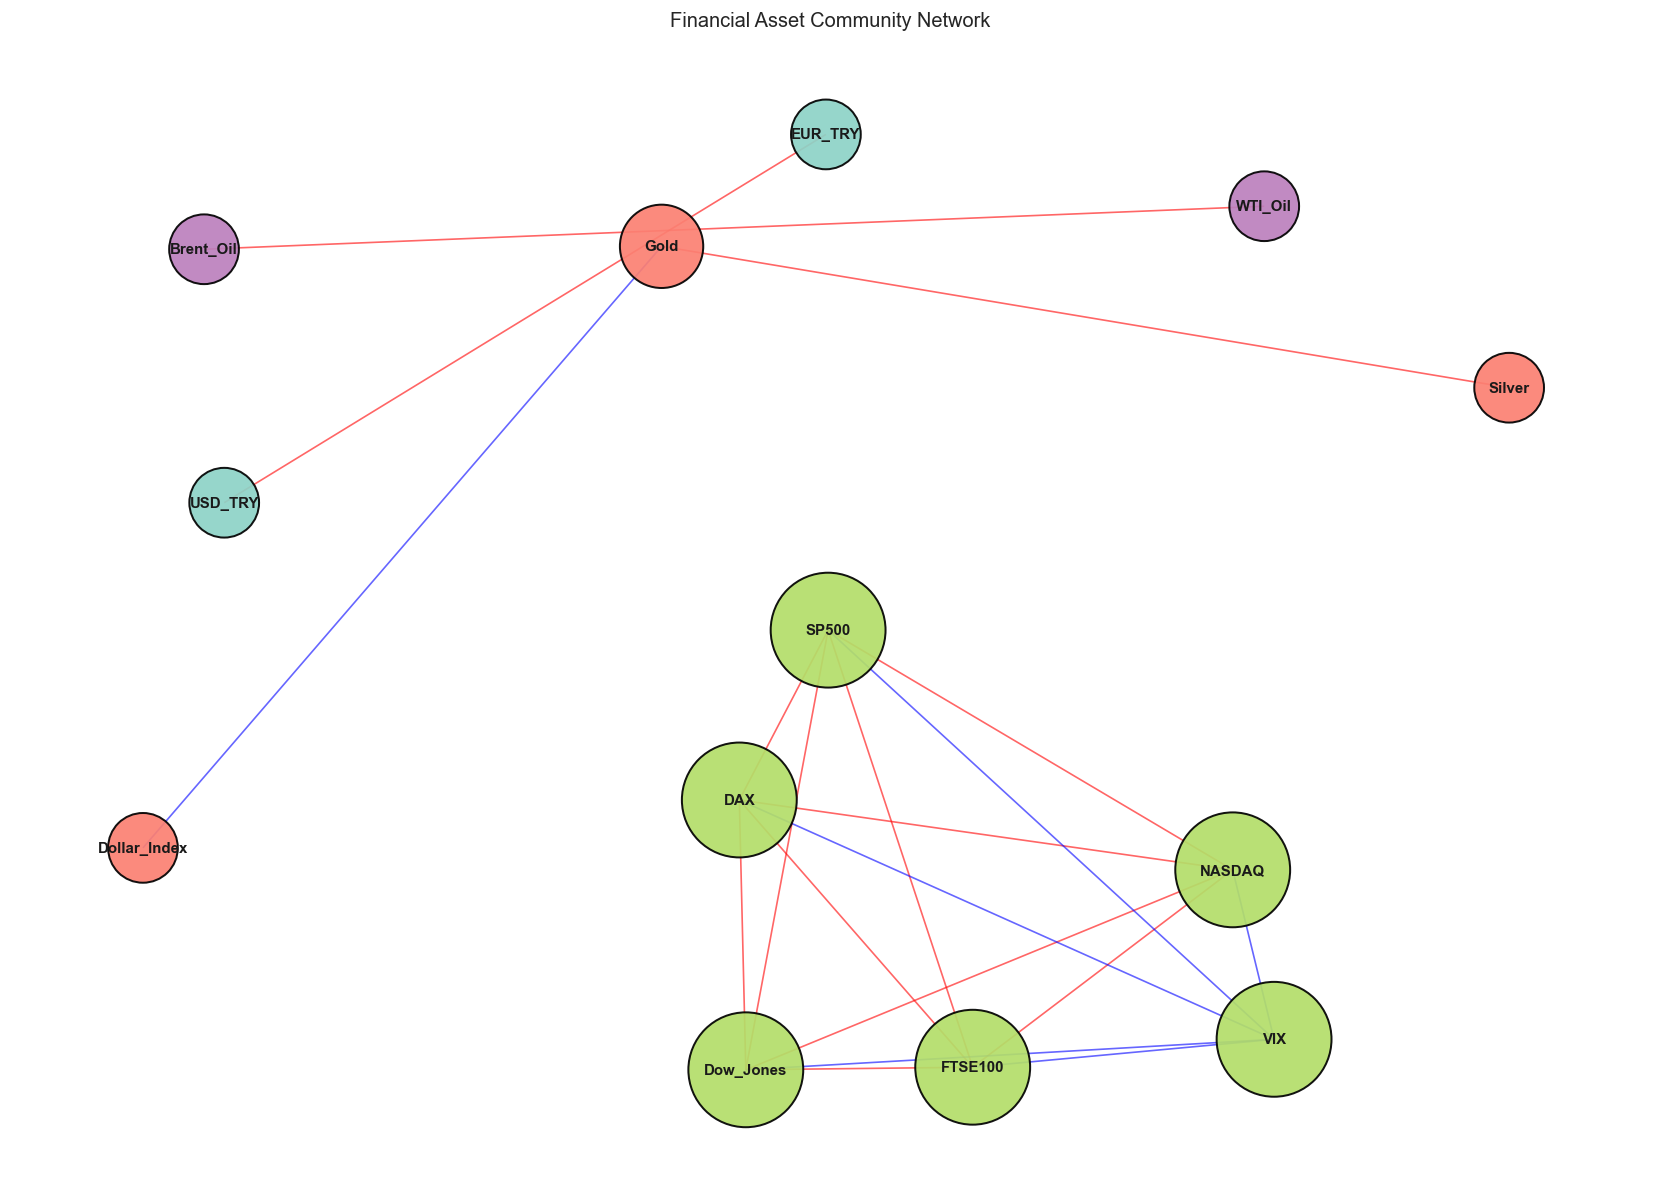

In [14]:
pos_comm = nx.spring_layout(community_G, seed=42, k=1.3)
communities = sorted(set(partition.values()))
color_map = plt.cm.Set3
node_colors = [color_map(communities.index(partition[node]) / max(len(communities), 1)) for node in community_G.nodes()]
node_sizes = [nx.degree_centrality(community_G)[node] * 9000 + 1000 for node in community_G.nodes()]

plt.figure(figsize=(14, 10))
nx.draw_networkx_nodes(community_G, pos_comm, node_size=node_sizes, node_color=node_colors, edgecolors="black", linewidths=1.2, alpha=0.92)
nx.draw_networkx_edges(community_G, pos_comm, edgelist=[(u, v) for u, v in community_G.edges() if community_G[u][v]["correlation"] > 0], edge_color="red", alpha=0.6)
nx.draw_networkx_edges(community_G, pos_comm, edgelist=[(u, v) for u, v in community_G.edges() if community_G[u][v]["correlation"] < 0], edge_color="blue", alpha=0.6)
nx.draw_networkx_labels(community_G, pos_comm, font_size=9, font_weight="bold")
plt.title("Financial Asset Community Network")
plt.axis("off")
plt.tight_layout()
plt.savefig(GRAPH_DIR / "community_network.png", dpi=300, bbox_inches="tight")
plt.show()

## 14. Kısa Dayanıklılık Analizi

Bu bölümde ağın merkezi düğümlere karşı nasıl değiştiğini görmek için kısa bir dayanıklılık analizi yapıldı. Önce en yüksek degree centrality değerine sahip düğüm ağdan çıkarıldı. Daha sonra en yüksek betweenness centrality değerine sahip düğüm çıkarılarak ağ ölçütleri yeniden hesaplandı.

Bu senaryonun amacı, kritik görünen bir varlık çıkarıldığında ağın bağlantı yapısının ne kadar değiştiğini anlamaktır. Kenar sayısı, yoğunluk, bileşen sayısı ve en büyük bileşen büyüklüğü karşılaştırıldı.

In [15]:
def robustness_summary(graph, scenario, removed_node="-"):
    components = list(nx.connected_components(graph))
    return {
        "Scenario": scenario,
        "Removed node": removed_node,
        "Nodes": graph.number_of_nodes(),
        "Edges": graph.number_of_edges(),
        "Density": nx.density(graph),
        "Connected components": len(components),
        "Largest component size": max((len(component) for component in components), default=0),
        "Average clustering": nx.average_clustering(graph) if graph.number_of_nodes() else 0,
    }

top_degree_node = centrality_df["Degree_Centrality"].idxmax()
top_betweenness_node = centrality_df["Betweenness_Centrality"].idxmax()

robustness_rows = [robustness_summary(G, "Original network")]
for scenario, node in [
    ("Remove highest degree node", top_degree_node),
    ("Remove highest betweenness node", top_betweenness_node),
]:
    H = G.copy()
    H.remove_node(node)
    robustness_rows.append(robustness_summary(H, scenario, node))

robustness_df = pd.DataFrame(robustness_rows)
robustness_df.to_csv(METRICS_DIR / "robustness_analysis.csv", index=False)
robustness_df

,Scenario,Removed node,Nodes,Edges,Density,Connected components,Largest component size,Average clustering
0,Original network,-,18,19,0.124183,9,6,0.333333
1,Remove highest degree node,SP500,17,14,0.102941,9,5,0.294118
2,Remove highest betweenness node,VIX,17,14,0.102941,9,5,0.294118


## 15. Sonuç ve Genel Yorum

Analiz sonucunda finansal varlıkların tamamen dağınık bir yapı oluşturmadığı, belirli piyasa segmentleri etrafında kümelendiği görülmektedir. Küresel hisse senedi endeksleri ve VIX, ağın en belirgin çekirdek yapısını oluşturur. Değerli metaller, döviz kurları ve enerji varlıkları ise daha küçük ve ayrışan gruplar halinde konumlanır.

Bu çalışma, sosyal ağ analizi yaklaşımının finansal piyasaları sistem düzeyinde incelemek için kullanılabileceğini göstermektedir. Korelasyon tabanlı ağ modeli sayesinde hangi varlıkların merkezde yer aldığı, hangi varlıkların köprü rolü oynadığı ve piyasa segmentlerinin nasıl topluluklara ayrıldığı birlikte değerlendirilebilir.